In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

import jax.numpy as jnp
import numpy as np

from ajx.constraints import ConstraintType
from ajx.example_environments.dlo_attached import DLOAttached, DLOAttachedSettings
from ajx.example_graphics.application import Application
from ajx.example_graphics.environment_scene import EnvironmentScene
from ajx.simulation import SimulationSettings, Solver


def setup_dlo_environment(timestep, pgs_iterations, solver):

    env = DLOAttached(
        sim_settings=SimulationSettings(
            timestep, True, solver, pgs_iterations
        ),
        env_settings=DLOAttachedSettings(
            n_bodies=25,
            body_length=0.08,
            constraint_type=ConstraintType.SE3.value,
            hinge_motor_attachment=True
        ),
    )
    yz_linear_stiffness = 1e4
    x_linear_stiffness = 1e4
    bend_linear_stiffness = 1e3
    torsion_linear_stiffness = 1e4

    yz_quadratic_stiffness = 0.0
    x_quadratic_stiffness = 0.0
    bend_quadratic_stiffness = 0.0
    torsion_quadratic_stiffness = 0.0

    env_param = env.default_param.tree_replace(
        src={
            "sparse_param.coupled_constraint_param": {
                "linear_stiffness.data": jnp.array(
                    [
                        x_linear_stiffness,
                        yz_linear_stiffness,
                        yz_linear_stiffness,
                        bend_linear_stiffness,
                        bend_linear_stiffness,
                        torsion_linear_stiffness,
                    ]
                ),
                "quadratic_stiffness.data": jnp.array(
                    [
                        x_quadratic_stiffness,
                        yz_quadratic_stiffness,
                        yz_quadratic_stiffness,
                        bend_quadratic_stiffness,
                        bend_quadratic_stiffness,
                        torsion_quadratic_stiffness,
                    ]
                ),
                "is_velocity": jnp.array([0, 0, 0, 0, 0, 0], dtype=bool),
            }
        }
    )
    env_param = env_param.tree_replace(
        {
            "constraint_param.is_velocity.attachment_hinge": {5: True},
        }
    )

    return env, env_param
        

## Use the Direct solver as ground truth

In [3]:
horizon = 10
timestep = 0.01
pgs_iterations = 300

env, env_param = setup_dlo_environment(timestep, pgs_iterations, Solver.SPARSE_LINEAR)

state = env.state_from_angles(env_param)
env_step = jax.jit(env.step)
period = 3
u = np.sin(2*np.pi/period * np.arange(horizon)*timestep)
u = jnp.array(u)

# Prepare to store rigid body data
loose_end_id = env_param.rigid_body_param.names.index("body24")
dlo_pos_x = []
dlo_pos_z = []

# Simulation loop
for i in range(horizon):
    # Step the environment and store the observation
    state, observations = env_step(state, u, env_param)
    dlo_pos_x.append(state.conf.pos[:,0])
    dlo_pos_z.append(state.conf.pos[:,2])

# To store results for plotting 
dlo_position = {"DIRECT_SOLVER": {"x": np.array(dlo_pos_x), "z": np.array(dlo_pos_z)}}
dz = {"DIRECT_SOLVER": dlo_position["DIRECT_SOLVER"]["z"][:,loose_end_id]}

jax.clear_caches()  # Workaround

Exception: 

# Use the Iterative Solver for different number of iterations

In [ ]:
NUMBER_OF_ITERATIONS = (300, 600, 1200, 2400)


loose_end_id = env_param.rigid_body_param.names.index("body24")
dlo_pos_x = []
dlo_pos_z = []


for Nit in NUMBER_OF_ITERATIONS:
    
    # To setup simulation environment
    env, env_param = setup_dlo_environment(timestep, Nit, Solver.DENSE_PGS)
    state = env.state_from_angles(env_param)
    env_step = jax.jit(env.step)

    tmp_x = []
    tmp_z = []

    # Simulation loop
    for i in range(horizon):
        # Step the environment and store the observation
        state, observations = env_step(state, u, env_param)
        tmp_x.append(state.conf.pos[:,0])
        tmp_z.append(state.conf.pos[:,2])

    dlo_pos_x.append(np.array(tmp_x))
    dlo_pos_z.append(np.array(tmp_z))

    jax.clear_caches()  # Workaround

# To store results for plotting
dlo_position["ITERATIVE_SOLVER"] = {"x": np.array(dlo_pos_x), "z": np.array(dlo_pos_z)}
dz["ITERATIVE_SOLVER"] = np.array(dlo_position["ITERATIVE_SOLVER"]["z"][:,:,loose_end_id])

KeyboardInterrupt: 

(4, 10)


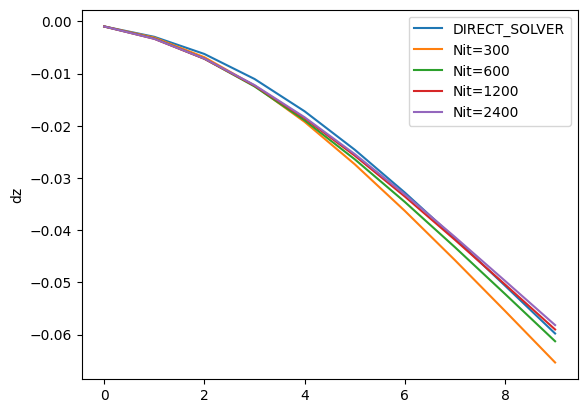

In [ ]:
from matplotlib import pyplot as plt
print(dz["ITERATIVE_SOLVER"].shape)
plt.figure()
plt.plot(np.arange(horizon), dz["DIRECT_SOLVER"], label="DIRECT_SOLVER")
for j in range(len(NUMBER_OF_ITERATIONS)):
    plt.plot(np.arange(horizon), dz["ITERATIVE_SOLVER"][j,:], label=f"Nit={NUMBER_OF_ITERATIONS[j]}")
plt.ylabel("dz")
plt.legend()
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
import matplotlib as mpl
from IPython.display import HTML

# To precompute axis limits
x_direct = dlo_position["DIRECT_SOLVER"]["x"]
z_direct = dlo_position["DIRECT_SOLVER"]["z"]
x_iter = dlo_position["ITERATIVE_SOLVER"]["x"]
z_iter = dlo_position["ITERATIVE_SOLVER"]["z"]
x_min = np.min([x_direct.min(), x_iter.min()])
x_max = np.max([x_direct.max(), x_iter.max()])
z_min = np.min([z_direct.min(), z_iter.min()])
z_max = np.max([z_direct.max(), z_iter.max()])

# Make a figure and use it for an animation
fig, ax = plt.subplots()
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_xlim([x_min-0.05, x_max + 0.1])
ax.set_ylim([z_min, z_max + 0.1])
ax.grid(True)



# Initialize lines for both direct and iterative solver
line_direct, = ax.plot([], [], 'o-', label="Direct Solver")
iter_lines = []
for j in range(len(NUMBER_OF_ITERATIONS)):
    line, = ax.plot([], [], 's-', label=f"Nit={NUMBER_OF_ITERATIONS[j]}")
    iter_lines.append(line)
ax.legend(loc="lower left")

def update(t):
    line_direct.set_data(
        dlo_position["DIRECT_SOLVER"]["x"][t, :],
        dlo_position["DIRECT_SOLVER"]["z"][t, :]
    )
    for j, line in enumerate(iter_lines):
        line.set_data(
            dlo_position["ITERATIVE_SOLVER"]["x"][j, t, :],
            dlo_position["ITERATIVE_SOLVER"]["z"][j, t, :]
        )

    return [line_direct, *iter_lines]

# Display animation
mpl.rcParams['animation.embed_limit'] = 50
anim = FuncAnimation(fig, update, frames=horizon, interval=timestep*1000, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

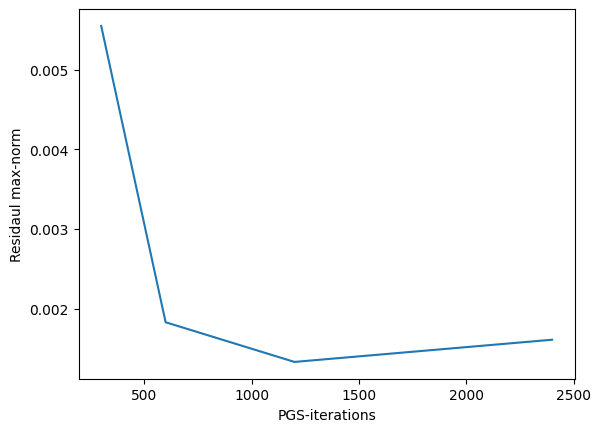

In [ ]:
residual = []
for j in range(dz["ITERATIVE_SOLVER"].shape[0]):
    residual.append(np.linalg.norm(dz["DIRECT_SOLVER"] - dz["ITERATIVE_SOLVER"][j,:], ord=np.inf))

plt.figure()
plt.plot(np.array(NUMBER_OF_ITERATIONS), np.array(residual))
plt.xlabel("PGS-iterations")
plt.ylabel("Residaul max-norm")
plt.show()
